In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
#from transformers import TFBertForSequenceClassification, BertTokenizer
from sklearn.model_selection import KFold, train_test_split
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    AutoModelForSequenceClassification,
    AdamW,
    get_linear_schedule_with_warmup,
)
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix
import torch
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset
from collections import Counter



In [ ]:
batch_size = 32
num_epochs = 10
k_folds = 10

In [ ]:
financial_data = pd.read_csv(
    "AllAgree2.csv", encoding="UTF-8", names=["sentiment", "NewsHeadline"]
)

In [ ]:
def encode_sentiments_values(df):
    possible_sentiments = df.sentiment.unique()
    sentiment_dict = {}

    for index, possible_sentiment in enumerate(possible_sentiments):
        sentiment_dict[possible_sentiment] = index

    # Encode all the sentiment values
    df["label"] = df.sentiment.replace(sentiment_dict)

    return df, sentiment_dict


In [ ]:
# Encode the sentiment column
financial_data, sentiment_dict = encode_sentiments_values(financial_data)



<ipython-input-4-155f0f8297c1>:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["label"] = df.sentiment.replace(sentiment_dict)


In [ ]:
print(sentiment_dict)
print(len(sentiment_dict))

{'neutral': 0, 'positive': 1, 'negative': 2}
3


In [ ]:
financial_data['data_type'] = ['not_set']*financial_data.shape[0]

In [ ]:
financial_data.head()

,sentiment,NewsHeadline,label,data_type
0,neutral,"According to Gran , the company has no plans t...",0,not_set
1,positive,"For the last quarter of 2010 , Componenta 's n...",1,not_set
2,positive,"In the third quarter of 2010 , net sales incre...",1,not_set
3,positive,Operating profit rose to EUR 13.1 mn from EUR ...,1,not_set
4,positive,"Operating profit totalled EUR 21.1 mn , up fro...",1,not_set


In [ ]:
financial_data.groupby(['sentiment', 'label', 'data_type']).count()

,,,NewsHeadline
sentiment,label,data_type,
negative,2,not_set,303
neutral,0,not_set,1391
positive,1,not_set,570


In [ ]:
# Function to plot class distribution
import matplotlib.pyplot as plt
import seaborn as sns

def plot_class_distribution(df, title):
    sns.countplot(x='label', data=df)
    plt.title(title)
    plt.xlabel('Class')
    plt.ylabel('Frequency')
    plt.xticks([0, 1, 2], ['Neutral', 'Positive', 'Negative',])
    plt.show()



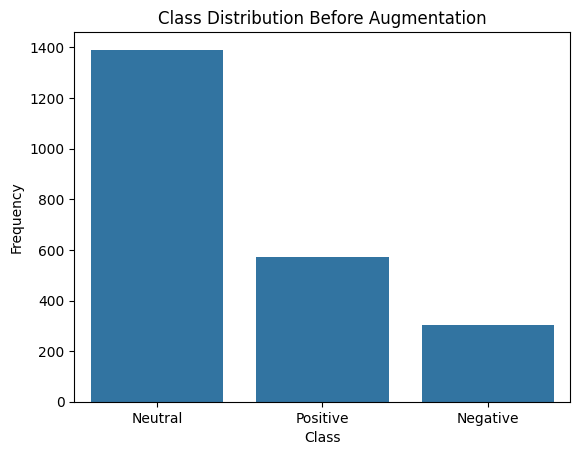

In [ ]:
plot_class_distribution(financial_data, "Class Distribution Before Augmentation")

In [ ]:
!pip install pandas scikit-learn nlpaug

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 30.6 MB/s eta 0:00:00


In [ ]:
import nlpaug.augmenter.word as naw

def synonym_augmentation(text, augmenter, num_aug=2):
    augmented_texts = []
    for _ in range(num_aug):
        augmented_text = str(augmenter.augment(text)).replace("[", "")
        augmented_text = augmented_text.replace("]", "")
        augmented_texts.append(augmented_text)
    return augmented_texts

def augment_dataset(df_origin):

    # Initialize the synonym augmenter
    synonym_aug = naw.SynonymAug(aug_src='wordnet')  # Based wordnet

    # Apply augmentation to minority class
    minority_df1 = df_origin[df_origin['label'] == 1]
    augmented_positive = []

    minority_df2 = df_origin[df_origin['label'] == 2]
    augmented_negative = []

    for text in minority_df1['NewsHeadline']:
        augmented = synonym_augmentation(text, synonym_aug, num_aug=1)
        augmented_positive.extend(augmented)

    for text in minority_df2['NewsHeadline']:
        augmented = synonym_augmentation(text, synonym_aug, num_aug=3)
        augmented_negative.extend(augmented)

    # Create augmented DataFrame
    augmented_df1 = pd.DataFrame({
        'NewsHeadline': augmented_positive,
        'label': [1]*len(augmented_positive),
        'sentiment': 'positive'
    })


    # Create augmented DataFrame
    augmented_df2 = pd.DataFrame({
        'NewsHeadline': augmented_negative,
        'label': [2]*len(augmented_negative),
        'sentiment': 'negative'
    })

    # Combine original and augmented data
    df_augmented = pd.concat([df_origin, augmented_df1, augmented_df2]).reset_index(drop=True)
    return df_augmented

In [ ]:
# Load Tokenizer
tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")

# Tokenize the text columns
def tokenize_texts(text1):
    return tokenizer(text1.tolist(), padding='max_length', truncation=True, max_length=128)


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
def f1_score_func(preds, labels):

    # Setting up the preds to axis=1
    # Flatting it to a single iterable list of array
    preds_flat = np.argmax(preds, axis=1).flatten()

    # Flattening the labels
    labels_flat = labels.flatten()

    # Returning the f1_score as define by sklearn
    return f1_score(labels_flat, preds_flat, average='weighted')

In [ ]:
def accuracy_func(preds, labels):

    # Setting up the preds to axis=1
    # Flatting it to a single iterable list of array
    preds_flat = np.argmax(preds, axis=1).flatten()

    # Flattening the labels
    labels_flat = labels.flatten()

    # Returning the f1_score as define by sklearn
    return accuracy_score(labels_flat, preds_flat)

In [ ]:
from torch.nn import CrossEntropyLoss

def evaluate(dataloader_val):

    model.eval()

    loss_val_total = 0
    total_loss = 0
    predictions, true_vals = [], []

    loss_fn = CrossEntropyLoss()

    for batch in tqdm(dataloader_val):

        batch = tuple(b.to(device) for b in batch)

        inputs = {'input_ids':      batch[0],
                  'attention_mask': batch[1],
                  'labels':         batch[2],
                 }

        with torch.no_grad():
            outputs = model(**inputs)



        loss = outputs[0]
        logits = outputs[1]
        loss_val_total += loss.item()

        # Calculate loss for the batch ( Added for entropy loss 02.11.2024 )
        loss = loss_fn(logits, batch[2])
        total_loss += loss.item()  # Sum up batch loss

        logits = logits.detach().cpu().numpy()
        label_ids = inputs['labels'].cpu().numpy()
        predictions.append(logits)
        true_vals.append(label_ids)

    #loss_val_avg = loss_val_total/len(dataloader_val)
    loss_val_avg = total_loss/len(dataloader_val)

    predictions = np.concatenate(predictions, axis=0)
    true_vals = np.concatenate(true_vals, axis=0)

    return loss_val_avg, predictions, true_vals

In [ ]:
def accuracy_per_class(preds, labels):
    label_dict_inverse = {v: k for k, v in sentiment_dict.items()}

    preds_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()

    # Iterating over all the unique labels
    # label_flat are the --> True labels
    for label in np.unique(labels_flat):
        # Taking out all the pred_flat where the True alable is the lable we care about.
        # e.g. for the label Happy -- we Takes all Prediction for true happy flag
        y_preds = preds_flat[labels_flat==label]
        y_true = labels_flat[labels_flat==label]
        print(f'Class: {label_dict_inverse[label]}')
        print(f'Accuracy: {len(y_preds[y_preds==label])}/{len(y_true)}\n')

In [ ]:
!pip install tqdm

In [ ]:
!rm /content/*.model

In [ ]:
# Divide into train set and validation set 8:2
train_df, val_df = train_test_split(financial_data, test_size=0.2, stratify=financial_data['label'])

In [ ]:
# Do augment on train set
train_df = augment_dataset(train_df)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


New Class Distribution After Augmentation:
Counter({0: 1113, 2: 968, 1: 912})


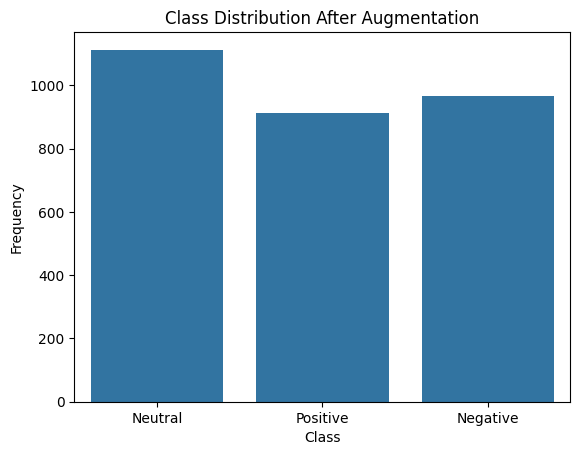

In [ ]:
# Plot the new class distribution of train_df after augmentation

print("New Class Distribution After Augmentation:")
print(Counter(train_df['label']))


plot_class_distribution(train_df, "Class Distribution After Augmentation")

In [ ]:
# Define K-fold cross-validation
kf = KFold(n_splits=k_folds, shuffle=True)

# # Data preparation: input texts and labels
# X_text = financial_data['NewsHeadline'].values
# y = financial_data['label'].values

In [ ]:
financial_data.loc[[1]]

,sentiment,NewsHeadline,label,data_type
1,positive,"For the last quarter of 2010 , Componenta 's n...",1,not_set


In [ ]:
def getSpecificDataFrame(indeces):
  retreived_df = financial_data.loc[[indeces[0]]]
  for i in range(1,len(indeces)):
    record_df = financial_data.loc[[indeces[i]]]
    retreived_df = pd.concat([record_df, retreived_df])

  return retreived_df


In [ ]:
!rm -rf /content/*.model

In [ ]:
from tqdm import tqdm
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler
from sklearn.metrics import accuracy_score, f1_score
from google.colab import files

best_accuracy = 0.0
best_loss = 0.0
early_stopping_counter = 0
patience = 11
best_model = []
total_sum_loss = 0.0
total_accuracy = 0.0
total_train_num = 0




for fold, (train_indices, val_indices) in enumerate(kf.split(financial_data['NewsHeadline'], financial_data['label'])):
    print(f"Training Fold {fold+1}/{k_folds}")

  #  print("TRAIN:", train_indices, "TEST:", val_indices)

    train_df = getSpecificDataFrame(train_indices)
    val_df = getSpecificDataFrame(val_indices)

    train_df = augment_dataset(train_df)

    encoded_data_train = tokenizer.batch_encode_plus(
        train_df["NewsHeadline"],
        return_tensors="pt",
        add_special_tokens=True,
        return_attention_mask=True,
        padding=True,
        max_length=128,
    )

    encoded_data_val = tokenizer.batch_encode_plus(
        val_df["NewsHeadline"],
        return_tensors="pt",
        add_special_tokens=True,
        return_attention_mask=True,
        padding=True,
        max_length=128,
    )

    input_ids_train = encoded_data_train['input_ids']
    attention_masks_train = encoded_data_train['attention_mask']
    labels_train = torch.tensor(train_df['label'])

    input_ids_val = encoded_data_val['input_ids']
    attention_masks_val = encoded_data_val['attention_mask']
    labels_val = torch.tensor(val_df['label'].to_numpy())

    dataset_train = TensorDataset(input_ids_train, attention_masks_train, labels_train)
    dataset_val = TensorDataset(input_ids_val, attention_masks_val, labels_val)

    # We Need two different dataloder
    dataloader_train = DataLoader(dataset_train,
                                  sampler=RandomSampler(dataset_train),
                                  batch_size=batch_size)

    dataloader_validation = DataLoader(dataset_val,
                                  sampler=RandomSampler(dataset_val),
                                  batch_size=batch_size)


    # Load BERT model with classification head
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
 #   model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")
    model = BertForSequenceClassification.from_pretrained("ProsusAI/finbert", num_labels=len(sentiment_dict))
    model.to(device)


    # Optimizer and learning rate scheduler
    optimizer = AdamW(model.parameters(), lr=2e-5)
    total_steps = len(dataloader_train) * num_epochs
    warmup_proportion = 0.1  # 10%
    warmup_steps = int(total_steps * warmup_proportion)
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

    for epoch in tqdm(range(1, num_epochs+1)):

        model.train()          # Sending our model in Training mode

        loss_train_total = 0   # Setting the training loss to zero initially

        # Setting up the Progress bar to Moniter the progress of training
        progress_bar = tqdm(dataloader_train, desc='Epoch {:1d}'.format(epoch), leave=False, disable=False)
        for batch in progress_bar:

            model.zero_grad() # As we not working with thew RNN's

            # As our dataloader has '3' iteams so batches will be the Tuple of '3'
            batch = tuple(b.to(device) for b in batch)

            # INPUTS
            # Pulling out the inputs in the form of dictionary
            inputs = {'input_ids':      batch[0],
                      'attention_mask': batch[1],
                      'labels':         batch[2],
                    }


            # OUTPUTS
            outputs = model(**inputs) # '**' Unpacking the dictionary stright into the input

            loss = outputs[0]
            loss_train_total += loss.item()
            loss.backward()           # backpropagation

            # Gradient Clipping -- Taking the Grad. & gives it a NORM value ~ 1
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            scheduler.step()

            progress_bar.set_postfix({'training_loss': '{:.3f}'.format(loss.item()/len(batch))})

        tqdm.write(f'\nEpoch {epoch}')

        # Calculate metrics for evaluations
        loss_train_avg = loss_train_total/len(dataloader_train)
        tqdm.write(f'Training loss: {loss_train_avg}')

        val_loss, predictions, true_vals = evaluate(dataloader_validation)
        val_f1 = f1_score_func(predictions, true_vals)
        val_accuracy = accuracy_func(predictions, true_vals) #(true_vals, predictions)
        tqdm.write(f'Validation loss: {val_loss}')
        tqdm.write(f'F1 Score (Weighted): {val_f1}')
        tqdm.write(f'Accuracy: {val_accuracy}')

        total_sum_loss = total_sum_loss + val_loss
        total_accuracy = total_accuracy + val_accuracy
        total_train_num = total_train_num + 1

        if(epoch == 1):
          best_loss = val_loss

        #if(val_accuracy> best_accuracy):
        if(val_loss < best_loss):
          #best_accuracy = val_accuracy
          best_loss = val_loss
          early_stopping_counter = 0
          #version = f'{fold}_{epoch}_{int(best_accuracy*10000)}'
          version = f'{fold}_{epoch}_{val_loss}'
          best_model.append(version)
          print(f"appending the information of best model: {best_model}")
          torch.save(model.state_dict(), f'{fold+1}_finetunedCV_BERT_epoch_{epoch}.model')

          #files.download(f'/content/best_model_{version}.pth')

        else:
            early_stopping_counter += 1
            if early_stopping_counter >= patience:
                print(f"Early stopping: No improvement in {patience} epochs.")
                early_stopping_counter = 0
                best_accuracy = 0.0
                best_loss = 0.0
                break

mean_loss = total_sum_loss / total_train_num
mean_accuracy = total_accuracy / total_train_num

print(f'Mean of cross entropy validation loss: {mean_loss}')
print(f'Mean of validation Accuracy: {mean_accuracy}')


Training Fold 1/10


/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:2888: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
  0%|          | 0/10 [01:15<?, ?it/s]


Epoch 1
Training loss: 1.5035347436155593


...

Validation loss: 0.0704423423812841
F1 Score (Weighted): 0.9824461150783219
Accuracy: 0.9823008849557522



 90%|█████████ | 9/10 [14:07<01:24, 84.67s/it]


Epoch 10
Training loss: 0.0010214824869763106



100%|██████████| 10/10 [14:08<00:00, 84.81s/it]

Validation loss: 0.06778185685834615
F1 Score (Weighted): 0.9824461150783219
Accuracy: 0.9823008849557522
Mean of cross entropy validation loss: 0.1728596475438826
Mean of validation Accuracy: 0.9602725039959449


In [ ]:
_, predictions, true_vals = evaluate(dataloader_validation)

100%|██████████| 8/8 [00:00<00:00,  9.41it/s]


In [ ]:
accuracy_per_class(predictions, true_vals)

Class: neutral
Accuracy: 132/133

Class: positive
Accuracy: 64/66

Class: negative
Accuracy: 22/27



In [ ]:
from tqdm import tqdm
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler
from sklearn.metrics import accuracy_score, f1_score
from google.colab import files

best_accuracy = 0.0
best_loss = 0.0
early_stopping_counter = 0
patience = 11
best_model = []
total_sum_loss = 0.0
total_accuracy = 0.0
total_train_num = 0




for fold, (train_indices, val_indices) in enumerate(kf.split(financial_data['NewsHeadline'], financial_data['label'])):
    train_df = getSpecificDataFrame(train_indices)
    val_df = getSpecificDataFrame(val_indices)

    train_df = augment_dataset(train_df)

    encoded_data_train = tokenizer.batch_encode_plus(
        train_df["NewsHeadline"],
        return_tensors="pt",
        add_special_tokens=True,
        return_attention_mask=True,
        padding=True,
        max_length=128,
    )

    encoded_data_val = tokenizer.batch_encode_plus(
        val_df["NewsHeadline"],
        return_tensors="pt",
        add_special_tokens=True,
        return_attention_mask=True,
        padding=True,
        max_length=128,
    )

    input_ids_train = encoded_data_train['input_ids']
    attention_masks_train = encoded_data_train['attention_mask']
    labels_train = torch.tensor(train_df['label'])

    input_ids_val = encoded_data_val['input_ids']
    attention_masks_val = encoded_data_val['attention_mask']
    labels_val = torch.tensor(val_df['label'].to_numpy())

    dataset_train = TensorDataset(input_ids_train, attention_masks_train, labels_train)
    dataset_val = TensorDataset(input_ids_val, attention_masks_val, labels_val)

    # We Need two different dataloder
    dataloader_train = DataLoader(dataset_train,
                                  sampler=RandomSampler(dataset_train),
                                  batch_size=batch_size)

    dataloader_validation = DataLoader(dataset_val,
                                  sampler=RandomSampler(dataset_val),
                                  batch_size=batch_size)


    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = BertForSequenceClassification.from_pretrained("ProsusAI/finbert", num_labels=len(sentiment_dict))
    model.to(device)


    # Optimizer and learning rate scheduler
    optimizer = AdamW(model.parameters(), lr=2e-5)
    total_steps = len(dataloader_train) * num_epochs
    warmup_proportion = 0.1  # 10%
    warmup_steps = int(total_steps * warmup_proportion)
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

    for epoch in tqdm(range(1, num_epochs+1)):

        model.train()          # Sending our model in Training mode

        loss_train_total = 0   # Setting the training loss to zero initially

        # Setting up the Progress bar to Moniter the progress of training
        progress_bar = tqdm(dataloader_train, desc='Epoch {:1d}'.format(epoch), leave=False, disable=False)
        for batch in progress_bar:

            model.zero_grad() # As we not working with thew RNN's

            # As our dataloader has '3' iteams so batches will be the Tuple of '3'
            batch = tuple(b.to(device) for b in batch)

            # INPUTS
            # Pulling out the inputs in the form of dictionary
            inputs = {'input_ids':      batch[0],
                      'attention_mask': batch[1],
                      'labels':         batch[2],
                    }
            # OUTPUTS
            outputs = model(**inputs) # '**' Unpacking the dictionary stright into the input

            loss = outputs[0]
            loss_train_total += loss.item()
            loss.backward()           # backpropagation

            # Gradient Clipping -- Taking the Grad. & gives it a NORM value ~ 1
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            scheduler.step()

            progress_bar.set_postfix({'training_loss': '{:.3f}'.format(loss.item()/len(batch))})

        tqdm.write(f'\nEpoch {epoch}')

        loss_train_avg = loss_train_total/len(dataloader_train)
        tqdm.write(f'Training loss: {loss_train_avg}')

        val_loss, predictions, true_vals = evaluate(dataloader_validation)
        val_f1 = f1_score_func(predictions, true_vals)
        val_accuracy = accuracy_func(predictions, true_vals) #(true_vals, predictions)
        tqdm.write(f'Validation loss: {val_loss}')
        tqdm.write(f'F1 Score (Weighted): {val_f1}')
        tqdm.write(f'Accuracy: {val_accuracy}')

        total_sum_loss = total_sum_loss + val_loss
        total_accuracy = total_accuracy + val_accuracy
        total_train_num = total_train_num + 1

        if(epoch == 1):
          best_loss = val_loss

        #print(f"Validation Accuracy for fold {fold+1}: {accuracy:.3f}")
        #files.download(f'{fold}_finetunedCV_BERT_epoch_{epoch}.model')

        #print(f"Validation Accuracy for fold {fold+1}: {accuracy:.3f}")
        #fold_results.append(accuracy)


        #if(val_accuracy> best_accuracy):
        if(val_loss < best_loss):
          #best_accuracy = val_accuracy
          best_loss = val_loss
          early_stopping_counter = 0
          #version = f'{fold}_{epoch}_{int(best_accuracy*10000)}'
          version = f'{fold}_{epoch}_{val_loss}'
          best_model.append(version)
          print(f"appending the information of best model: {best_model}")
          torch.save(model.state_dict(), f'{fold+1}_finetunedCV_BERT_epoch_{epoch}.model')
          #torch.save(model.state_dict(), f'best_model_{version}.pth')
          #print("saving best model to 'best_model.pth'... ")

          #files.download(f'/content/best_model_{version}.pth')

        else:
            early_stopping_counter += 1
            if early_stopping_counter >= patience:
                print(f"Early stopping: No improvement in {patience} epochs.")
                early_stopping_counter = 0
                best_accuracy = 0.0
                best_loss = 0.0
                break

mean_loss = total_sum_loss / total_train_num
mean_accuracy = total_accuracy / total_train_num

print(f'Mean of cross entropy validation loss: {mean_loss}')
print(f'Mean of validation Accuracy: {mean_accuracy}')


In [ ]:
def classification_report_func(labels, preds):

    # Setting up the preds to axis=1
    # Flatting it to a single iterable list of array
    preds_flat = np.argmax(preds, axis=1).flatten()

    # Flattening the labels
    labels_flat = labels.flatten()

    # Returning the f1_score as define by sklearn
    return classification_report(labels_flat, preds_flat)

In [ ]:
def confusion_matrix_func(labels,preds):

    # Setting up the preds to axis=1
    # Flatting it to a single iterable list of array
    preds_flat = np.argmax(preds, axis=1).flatten()

    # Flattening the labels
    labels_flat = labels.flatten()

    # Returning the f1_score as define by sklearn
    return confusion_matrix(labels_flat, preds_flat)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
print(classification_report_func(true_vals, predictions))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       133
           1       0.93      0.97      0.95        66
           2       0.96      0.81      0.88        27

    accuracy                           0.96       226
   macro avg       0.96      0.93      0.94       226
weighted avg       0.96      0.96      0.96       226



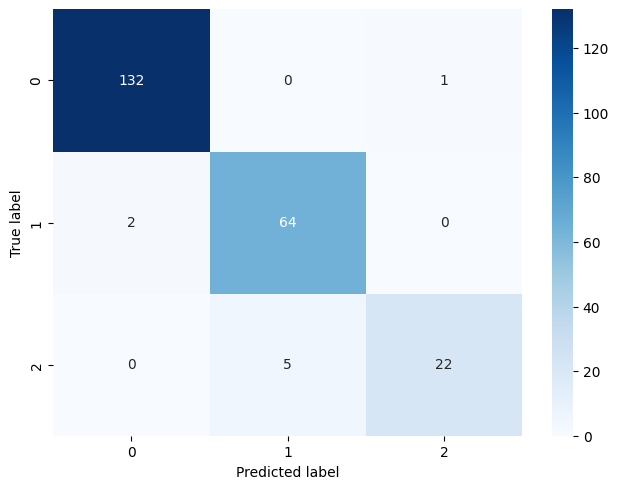

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def visualize(matrix):

  """
  This function takes in a matrix and generates a heatmap to visualize the data.

  Arguments:
  - matrix: a 2-dimensional matrix containing the data to be visualized.

  Returns:
  - None: The function does not return any value. It displays the heatmap plot directly.

  """
  con_mat_df = pd.DataFrame(matrix)
  sns.heatmap(con_mat_df, annot=True, fmt='g', cmap=plt.cm.Blues)
  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.show()

confusion_matrix = confusion_matrix_func(true_vals, predictions)
visualize(confusion_matrix)

In [ ]:
#Load a model
PATH = f"/content/10_finetunedCV_BERT_epoch_4.model"
checkpoint = torch.load(PATH)
model.load_state_dict(checkpoint, strict=False)

model.eval()

<ipython-input-42-6b8dc2b20f12>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(PATH)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
#Prediction

import torch
from tqdm import tqdm
#from transformers import Model # Made up package
result_class = ""
test_data = pd.DataFrame()
# select gpu when available, else work with cpu resources
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = BertForSequenceClassification.from_pretrained("ProsusAI/finbert", num_labels=len(sentiment_dict))
PATH = f"/content/10finetunedCVBERTepoch4.model"

model.load_state_dict(torch.load(PATH))#,map_location=torch.device('cpu')))
model = model.to(device) # Set model to gpu
model.eval();

#Load test data
test_data = pd.read_csv(
    "newsdata_all_dropping.csv", encoding="UTF-8"
)

# print(test_data.title.values)

# Add Sentiment column
#test_data["Sentiment"] =  ['not_set']*test_data.shape[0]

encoded_data_test = tokenizer.batch_encode_plus(
    test_data.title.values,
    #test_data.desc.values,
    return_tensors="pt",
    add_special_tokens=True,
    return_attention_mask=True,
    pad_to_max_length=True,
    max_length=128,
)

input_ids_test = encoded_data_test['input_ids']
attention_masks_test = encoded_data_test['attention_mask']
#labels_test = torch.tensor(financial_data[financial_data.data_type=='train'].label.values)
print(input_ids_test)

dataset_test = TensorDataset(input_ids_test, attention_masks_test)

# We Need two different dataloder
dataloader_test = DataLoader(dataset_test,
                              sampler=RandomSampler(dataset_test),
                              batch_size=batch_size)

# Make iteration with row of test_data
for i in range(0, len(test_data)):
  progress_bar = tqdm(dataloader_test, desc='Epoch {:1d}'.format(num_epochs), leave=False, disable=False)
  for batch in progress_bar:

      model.zero_grad() # As we not working with thew RNN's

      # As our dataloader has '2' iteams so batches will be the Tuple of '2'
      batch = tuple(b.to(device) for b in batch)

      # INPUTS
      # Pulling out the inputs in the form of dictionary
      inputs = {'input_ids':      batch[0],
                'attention_mask': batch[1]
              }

      # OUTPUTS
      with torch.no_grad():
        outputs = model(**inputs) # '**' Unpacking the dictionary stright into the input

      # Extract logits
      logits = outputs.logits
      #print(logits)
      # Predict classes
      predicted_classes = torch.argmax(logits, dim=1).tolist()

      #print(predicted_classes[0])

      if(predicted_classes[0] == 0):
        result_class = "Negative"
      elif(predicted_classes[0] == 1):
        result_class = "Neutral"
      else:
        result_class = "Positive"

      print(f"Predicted classes: {result_class}")
      test_data.loc[i, "Sentiment"] = result_class

      #print(test_data)
      #test_data.to_excel("test_data.xlsx")



<ipython-input-7-3b5a0939865a>:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(PATH))#,map_location=torch.device('cpu')))
Truncation was n

tensor([[  101,  3863,  1011,  ...,     0,     0,     0],
        [  101,  3863,  1011,  ...,     0,     0,     0],
        [  101,  9932, 21517,  ...,     0,     0,     0],
        ...,
        [  101, 15768,  2991,  ...,     0,     0,     0],
        [  101,  2274,  4436,  ...,     0,     0,     0],
        [  101,  1057,  1012,  ...,     0,     0,     0]])


Epoch 10:   5%|▍         | 2/42 [00:00<00:17,  2.29it/s]

Predicted classes: Positive
Predicted classes: Neutral


Epoch 10:  10%|▉         | 4/42 [00:01<00:10,  3.75it/s]

...

Epoch 10:  57%|█████▋    | 24/42 [00:05<00:04,  4.40it/s]

Predicted classes: Positive


Epoch 10:  60%|█████▉    | 25/42 [00:05<00:03,  4.39it/s]

Predicted classes: Neutral


Epoch 10:  62%|██████▏   | 26/42 [00:05<00:03,  4.41it/s]

In [ ]:
test_data.to_excel("test_data.xlsx")